In [ ]:
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

0.12.16


C:\Users\ojwin\AppData\Local\Temp\ipykernel_22380\3672182195.py:9: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(ad.__version__)


In [2]:
pre_adata = sc.read_10x_h5("GSM5574840_AD024_pre_raw_feature_bc_matrix.h5")
print(pre_adata.shape)
print("")
print(pre_adata .obs.head())
print("")
print(pre_adata.var.head())

(546771, 36601)

Empty DataFrame
Columns: []
Index: [AAACCTGAGAAACCAT-1, AAACCTGAGAAACCTA-1, AAACCTGAGAAACGCC-1, AAACCTGAGAAAGTGG-1, AAACCTGAGAACAATC-1]

                    gene_ids    feature_types  genome
MIR1302-2HG  ENSG00000243485  Gene Expression  GRCh38
FAM138A      ENSG00000237613  Gene Expression  GRCh38
OR4F5        ENSG00000186092  Gene Expression  GRCh38
AL627309.1   ENSG00000238009  Gene Expression  GRCh38
AL627309.3   ENSG00000239945  Gene Expression  GRCh38


c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


There is currently no supplied metadata for the obs

In [ ]:
pre_adata.var_names_make_unique() # makes each gene name unique

pre_adata.obs["patient"] = "AD024"
pre_adata.obs["treatment"] = "pre" # adding of sample specific metadata to the obs
pre_adata.obs["sample"] = "AD024_pre"

print(pre_adata)
print(pre_adata.obs.head())


AnnData object with n_obs × n_vars = 546771 × 36601
    obs: 'patient', 'treatment', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
                   patient treatment     sample
AAACCTGAGAAACCAT-1   AD024       pre  AD024_pre
AAACCTGAGAAACCTA-1   AD024       pre  AD024_pre
AAACCTGAGAAACGCC-1   AD024       pre  AD024_pre
AAACCTGAGAAAGTGG-1   AD024       pre  AD024_pre
AAACCTGAGAACAATC-1   AD024       pre  AD024_pre


In [4]:
sc.pp.calculate_qc_metrics(
    pre_adata,
    inplace=True,
    percent_top=None,
)

print(pre_adata.obs.head())

                   patient treatment     sample  n_genes_by_counts  \
AAACCTGAGAAACCAT-1   AD024       pre  AD024_pre                  1   
AAACCTGAGAAACCTA-1   AD024       pre  AD024_pre                  0   
AAACCTGAGAAACGCC-1   AD024       pre  AD024_pre                  3   
AAACCTGAGAAAGTGG-1   AD024       pre  AD024_pre                  0   
AAACCTGAGAACAATC-1   AD024       pre  AD024_pre                  1   

                    log1p_n_genes_by_counts  total_counts  log1p_total_counts  
AAACCTGAGAAACCAT-1                 0.693147           1.0            0.693147  
AAACCTGAGAAACCTA-1                 0.000000           0.0            0.000000  
AAACCTGAGAAACGCC-1                 1.386294           3.0            1.386294  
AAACCTGAGAAAGTGG-1                 0.000000           0.0            0.000000  
AAACCTGAGAACAATC-1                 0.693147           1.0            0.693147  


In [ ]:
print(pre_adata.obs[["total_counts", "n_genes_by_counts"]].describe())
print("")
print((pre_adata.obs["total_counts"] == 0).sum()) 
print((pre_adata.obs["n_genes_by_counts"] == 0).sum())

        total_counts  n_genes_by_counts
count  546771.000000      546771.000000
mean       81.194939          30.617449
std       715.871765         216.456897
min         0.000000           0.000000
25%         0.000000           0.000000
50%         1.000000           1.000000
75%         4.000000           4.000000
max     29426.000000        5355.000000

193241
193241


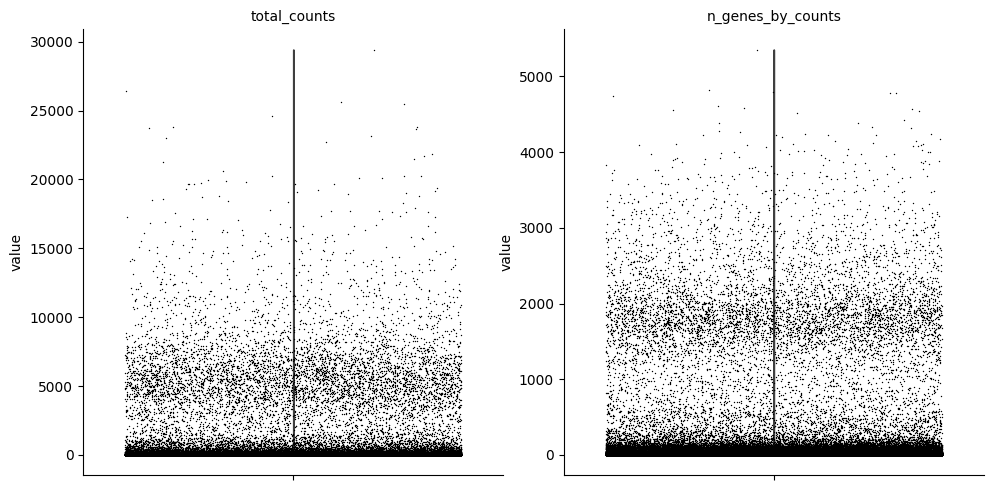

In [6]:
sc.pl.violin(
    pre_adata,
    ["total_counts", "n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
sc.pp.filter_cells(
    pre_adata,
    min_genes=250
) 

print(pre_adata.shape)

(8639, 36601)


In [8]:
print(pre_adata.obs[["total_counts", "n_genes_by_counts"]].describe())

       total_counts  n_genes_by_counts
count   8639.000000        8639.000000
mean    4573.334961        1514.154532
std     3444.221436         841.818917
min      316.000000         250.000000
25%     1418.000000         734.000000
50%     4452.000000        1614.000000
75%     6372.000000        1997.000000
max    29426.000000        5355.000000


We are now going to mark mitochondrial genes, if a cell has a high percentage of mitochondrial genes as opposed to nuclear genes, we can say that it is damaged in some way

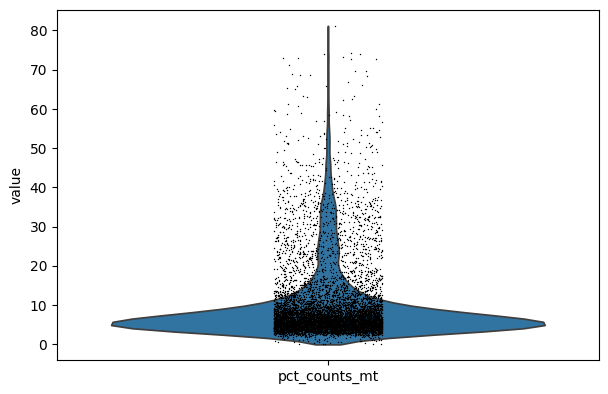

In [ ]:
pre_adata.var["mt"] = pre_adata.var_names.str.startswith("MT-") 

sc.pp.calculate_qc_metrics( 
    pre_adata,
    qc_vars=["mt"], # makes pct_mt_counts a new qc metric
    inplace=True,
) 

sc.pl.violin(
    pre_adata,
    ["pct_counts_mt"],
)


In [10]:
pre_adata = pre_adata[
    (pre_adata.obs["n_genes_by_counts"] > 500) &
    (pre_adata.obs["pct_counts_mt"] < 20)
].copy()

print(pre_adata.shape)

(6655, 36601)


In [11]:
sc.pp.scrublet(pre_adata, batch_key="sample")

print(pre_adata.obs[
    ["doublet_score", "predicted_doublet"]
].head())

print("")
print(pre_adata.obs["predicted_doublet"].value_counts())

                    doublet_score  predicted_doublet
AAACCTGAGAACTCGG-1       0.010944              False
AAACCTGAGACCGGAT-1       0.022273              False
AAACCTGAGAGGACGG-1       0.029502              False
AAACCTGAGGACAGCT-1       0.026044              False
AAACCTGAGGCTAGAC-1       0.044693              False

predicted_doublet
False    6432
True      223
Name: count, dtype: int64


In [12]:
pre_adata = pre_adata[
    ~pre_adata.obs["predicted_doublet"]
].copy()

print(pre_adata.shape)

(6432, 36601)


In [13]:
AD024_pre = pre_adata
AD024_pre.layers["counts"] = AD024_pre.X.copy()

In [14]:
def preprocessing(file, patient, treatment, sample):
    adata = sc.read_10x_h5(file)
    adata.var_names_make_unique()

    adata.obs["patient"] = patient
    adata.obs["treatment"] = treatment
    adata.obs["sample"] = sample

    sc.pp.calculate_qc_metrics(
    adata,
    inplace=True,
    percent_top=None,
    )

    sc.pp.filter_cells(adata, min_genes=250)

    adata.var["mt"] = adata.var_names.str.startswith("MT-")

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt"],
        inplace=True,
        percent_top=None,
    )

    adata = adata[
        (adata.obs["n_genes_by_counts"] >= 500)
        & (adata.obs["pct_counts_mt"] < 20)
    ].copy()

    sc.pp.scrublet(adata)

    adata = adata[
        ~adata.obs["predicted_doublet"]
    ].copy()

    adata.layers["counts"] = adata.X.copy()

    return adata


In [15]:
AD024_post = preprocessing(
    "GSM5574841_AD024_post_raw_feature_bc_matrix.h5",
    patient="AD024",
    treatment="post",
    sample="AD024_post",
)

print(AD024_post.shape)

c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(6776, 36601)


In [16]:
AD035_pre = preprocessing(
    "GSM5574842_AD035_pre_raw_feature_bc_matrix.h5",
    patient="AD035",
    treatment="pre",
    sample="AD035_pre",
)

print(AD035_pre.shape)

c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(10222, 36601)


In [17]:
AD035_post = preprocessing(
    "GSM5574843_AD035_post_raw_feature_bc_matrix.h5",
    patient="AD035",
    treatment="post",
    sample="AD035_post",
)

print(AD035_post.shape)

c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(8007, 36601)


In [18]:
AD036_pre = preprocessing(
    "GSM5574844_AD036_pre_raw_feature_bc_matrix.h5",
    patient="AD036",
    treatment="pre",
    sample="AD036_pre",
)

print(AD036_pre.shape)

c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(10389, 36601)


In [19]:
small_adata = sc.read_10x_h5("GSM5574845_AD036_post_raw_feature_bc_matrix.h5")
small_adata.var_names_make_unique()

sc.pp.calculate_qc_metrics(
    small_adata,
    inplace=True,
    percent_top=None,
)

print(
    "Cells with > 250 genes:",
    (small_adata.obs["n_genes_by_counts"] > 250).sum()
)

Cells with > 250 genes: 446


c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [20]:
AD051_pre = preprocessing(
    "GSM5574846_AD051_pre_raw_feature_bc_matrix.h5",
    patient="AD051",
    treatment="pre",
    sample="AD051_pre",
)

print(AD051_pre.shape)

c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(4537, 36601)


In [21]:
AD051_post = preprocessing(
    "GSM5574847_AD051_post_raw_feature_bc_matrix.h5",
    patient="AD051",
    treatment="post",
    sample="AD051_post",
)

print(AD051_post.shape)

c:\Users\ojwin\AppData\Local\Programs\Python\Python314\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(7912, 36601)


In [ ]:
samples = {
    "AD024_pre": AD024_pre,
    "AD024_post": AD024_post,
    "AD035_pre": AD035_pre,
    "AD035_post": AD035_post,
    "AD051_pre": AD051_pre,
    "AD051_post": AD051_post,
}

adata = ad.concat(
    samples,
    join="inner",
    merge="same",
    index_unique="_" # makes each cell_barcode unique
)

print(adata.shape)

print(adata.obs.head())
print(adata.obs["sample"].value_counts())
print(adata.obs["patient"].value_counts())
print(adata.obs["treatment"].value_counts())

(43886, 36601)
                             patient treatment     sample  n_genes_by_counts  \
AAACCTGAGAACTCGG-1_AD024_pre   AD024       pre  AD024_pre               1830   
AAACCTGAGACCGGAT-1_AD024_pre   AD024       pre  AD024_pre               1561   
AAACCTGAGAGGACGG-1_AD024_pre   AD024       pre  AD024_pre               1943   
AAACCTGAGGACAGCT-1_AD024_pre   AD024       pre  AD024_pre                924   
AAACCTGAGGCTAGAC-1_AD024_pre   AD024       pre  AD024_pre               2849   

                              log1p_n_genes_by_counts  total_counts  \
AAACCTGAGAACTCGG-1_AD024_pre                 7.512618        3870.0   
AAACCTGAGACCGGAT-1_AD024_pre                 7.353722        4799.0   
AAACCTGAGAGGACGG-1_AD024_pre                 7.572503        6411.0   
AAACCTGAGGACAGCT-1_AD024_pre                 6.829794        1645.0   
AAACCTGAGGCTAGAC-1_AD024_pre                 7.955074        9393.0   

                              log1p_total_counts  n_genes  total_counts_mt  \

In [23]:
print(adata.layers.keys())
print("")
print(
    adata.obs.groupby(
        ["patient", "treatment"],
        observed=True
    ).size()
)

KeysView(Layers with keys: counts)

patient  treatment
AD024    post          6776
         pre           6432
AD035    post          8007
         pre          10222
AD051    post          7912
         pre           4537
dtype: int64


In [24]:
sc.pp.normalize_total(adata, target_sum = 1000)
sc.pp.log1p(adata)


In [25]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000
)

adata.var["hvg"] = adata.var["highly_variable"]

adata.var["hvg"].value_counts()

hvg
False    34601
True      2000
Name: count, dtype: int64

In [26]:
adata_hvg = adata[:, adata.var["hvg"]].copy()

print(adata_hvg.shape)

(43886, 2000)


In [27]:
sc.tl.pca(adata_hvg)
adata_hvg.obsm["X_pca"].shape

(43886, 50)

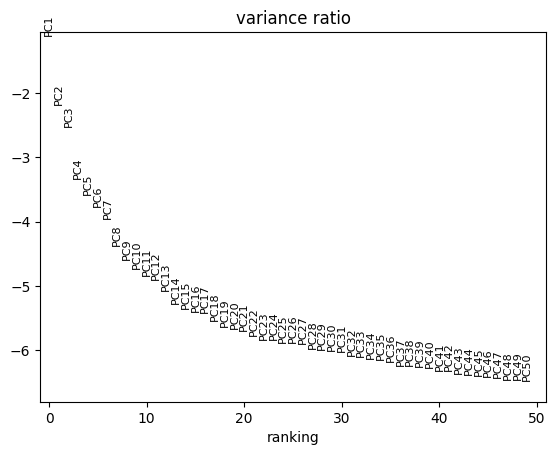

In [28]:
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, log=True)

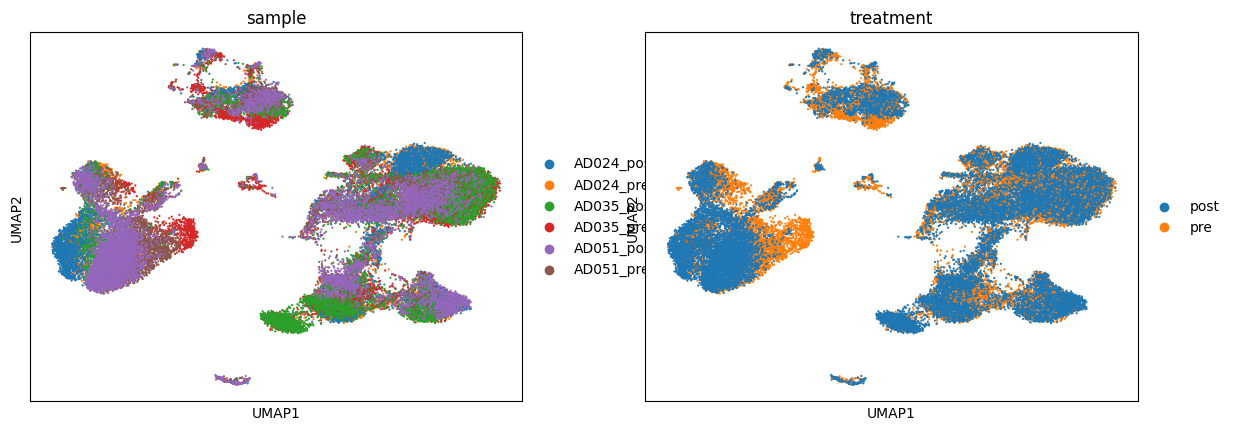

In [29]:
sc.pp.neighbors(
    adata_hvg,
    n_neighbors=15,
    n_pcs=40
)

sc.tl.umap(adata_hvg) #calculates umap coords

sc.pl.umap(adata_hvg, color=["sample", "treatment"], ncols=2, size=10) #plots umap coords

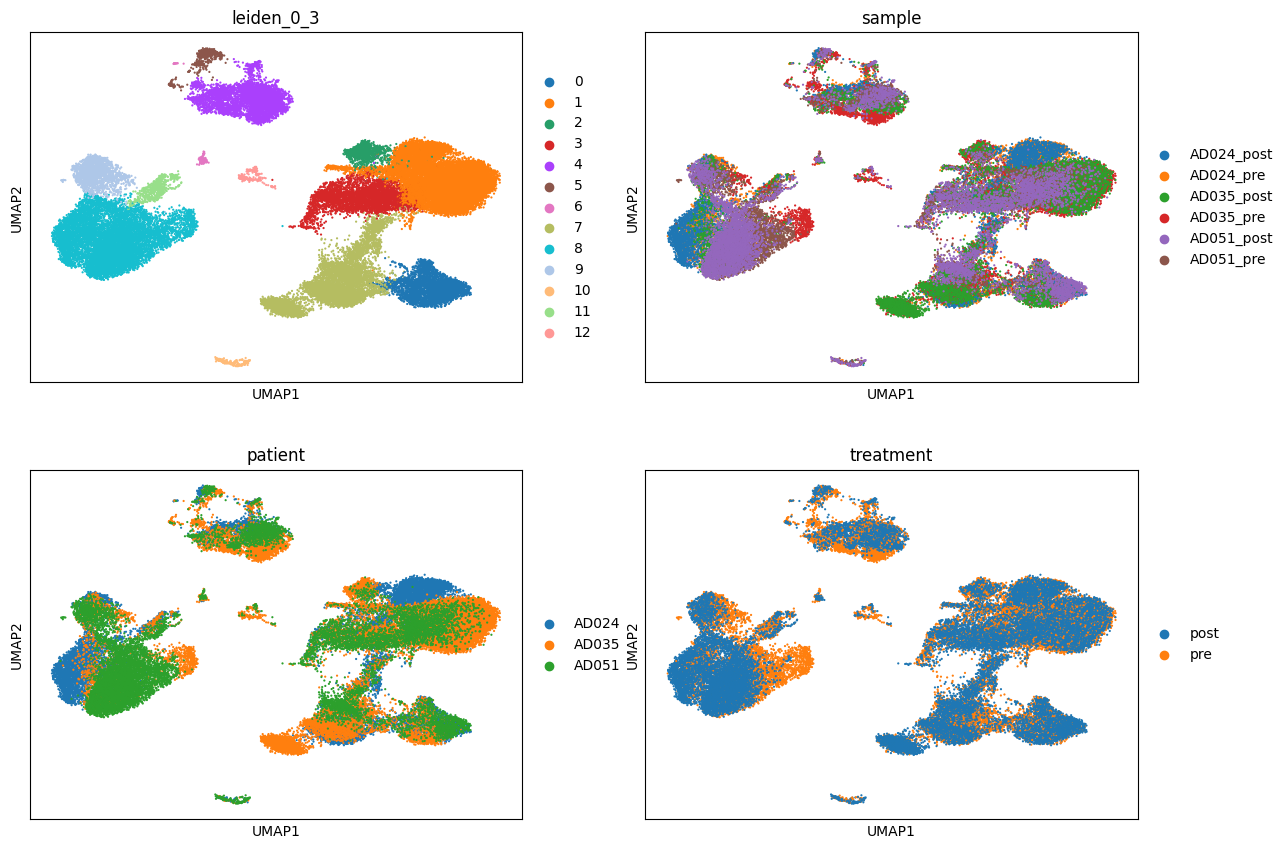

In [30]:
sc.tl.leiden(
    adata_hvg,
    resolution=0.3,
    flavor="igraph",
    n_iterations=2,
    key_added="leiden_0_3"
)

sc.pl.umap(
    adata_hvg,
    color=["leiden_0_3", "sample", "patient", "treatment"],
    ncols=2,
    size=10
)

In [31]:
print(
    adata_hvg.obs["leiden_0_3"]
    .value_counts()
    .sort_index()
)

leiden_0_3
0      3363
1     12404
2       939
3      3816
4      4485
5       539
6       158
7      6527
8      8861
9      1794
10      189
11      619
12      192
Name: count, dtype: int64


In [32]:
pd.crosstab(
    adata_hvg.obs["leiden_0_3"],
    adata_hvg.obs["treatment"],
    normalize="index"
).round(2)

treatment,post,pre
leiden_0_3,,
0,0.65,0.35
1,0.38,0.62
2,0.39,0.61
3,0.64,0.36
4,0.51,0.49
5,0.47,0.53
6,0.53,0.47
7,0.58,0.42
8,0.60,0.40


In [33]:
pd.crosstab(
    adata_hvg.obs["leiden_0_3"],
    adata_hvg.obs["sample"],
    normalize="index"
).round(2)

sample,AD024_post,AD024_pre,AD035_post,AD035_pre,AD051_post,AD051_pre
leiden_0_3,,,,,,
0,0.24,0.23,0.18,0.07,0.23,0.05
1,0.10,0.14,0.19,0.43,0.08,0.05
2,0.10,0.12,0.21,0.46,0.07,0.03
3,0.17,0.08,0.20,0.18,0.27,0.10
4,0.17,0.09,0.21,0.26,0.13,0.13
5,0.19,0.09,0.14,0.30,0.14,0.14
6,0.09,0.20,0.28,0.17,0.15,0.09
7,0.17,0.18,0.30,0.20,0.11,0.04
8,0.18,0.14,0.08,0.05,0.34,0.21


Cluster 12 looks a little perculiar, let's do some further inspection

In [34]:
adata_hvg.obs.groupby(
    "leiden_0_3",
    observed=True
)[
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
].median()

,total_counts,n_genes_by_counts,pct_counts_mt
leiden_0_3,,,
0,4125.0,1780.0,6.336312
1,5866.0,1695.0,3.978746
2,6090.0,1745.0,3.811117
3,6202.0,1962.5,4.409438
4,4662.0,1580.0,6.178834
5,4870.0,1642.0,6.053269
6,9425.0,2956.0,3.347144
7,4465.0,1702.0,5.765243
8,5546.0,1973.0,6.610169


In [35]:
adata_hvg.obs.groupby(
    "leiden_0_3",
    observed=True
)["doublet_score"].median()

leiden_0_3
0     0.019676
1     0.043286
2     0.050930
3     0.037753
4     0.017241
5     0.020444
6     0.071229
7     0.025279
8     0.040505
9     0.030439
10    0.051054
11    0.062025
12    0.082759
Name: doublet_score, dtype: float64

In [ ]:
adata_marker = adata.copy() # all genes need to be used in marker gene analysis, not just HVGs

adata_marker.obs["leiden"] = adata_hvg.obs["leiden_0_3"].copy() #copies cluster labels

adata_marker.obsm["X_umap"] = adata_hvg.obsm["X_umap"].copy() #copies umap coords

sc.tl.rank_genes_groups(
    adata_marker,
    groupby="leiden",
    method="wilcoxon", #the most common method in single cell analysis
    key_added="rank_genes_leiden",
)

In [37]:
marker_genes = {

    # T cells
    "T cells": [
        "CD3D", "CD3E", "TRAC"
    ],

    "CD4 T cells": [
        "IL7R", "LTB", "MAL", "CCR7"
    ],

    "Naive T cells": [
        "CCR7", "SELL", "TCF7", "LEF1", "MAL"
    ],

    "CD8 T cells": [
        "CD8A", "CD8B", "CCL5", "NKG7", "GZMK"
    ],

    "Regulatory T cells": [
        "FOXP3", "IL2RA", "CTLA4", "TIGIT"
    ],

    # NK cells
    "NK cells": [
        "NKG7", "GNLY", "KLRD1", "PRF1", "GZMB"
    ],

    # B cells
    "B cells": [
        "MS4A1", "CD79A", "CD79B", "CD74", "CD37"
    ],

    "Naive B cells": [
        "IGHD", "IGHM", "TCL1A", "FCER2", "IL4R"
    ],

    "Memory B cells": [
        "CD27", "CD37", "CD79A", "CD82", "TNFRSF13B"
    ],

    # Plasma cells / plasmablasts
    "Plasma cells": [
        "MZB1", "JCHAIN", "XBP1", "SDC1", "DERL3"
    ],

    # Monocytes
    "Classical monocytes": [
        "LYZ", "S100A8", "S100A9", "CTSD", "FCN1", "CD14"
    ],

    "Non-classical monocytes": [
        "FCGR3A", "MS4A7", "LST1", "IFITM3", "LILRB1"
    ],

    # Dendritic cells
    "cDC2": [
        "CD1C", "FCER1A", "CLEC10A", "CST3", "HLA-DRA"
    ],

    "cDC1": [
        "CLEC9A", "BATF3", "CADM1", "XCR1"
    ],

    "pDC": [
        "LILRA4", "GZMB", "PLD4", "IL3RA", "TCF4"
    ],

    # Platelets
    "Platelets": [
        "PPBP", "PF4", "NRGN", "GNG11"
    ],
}

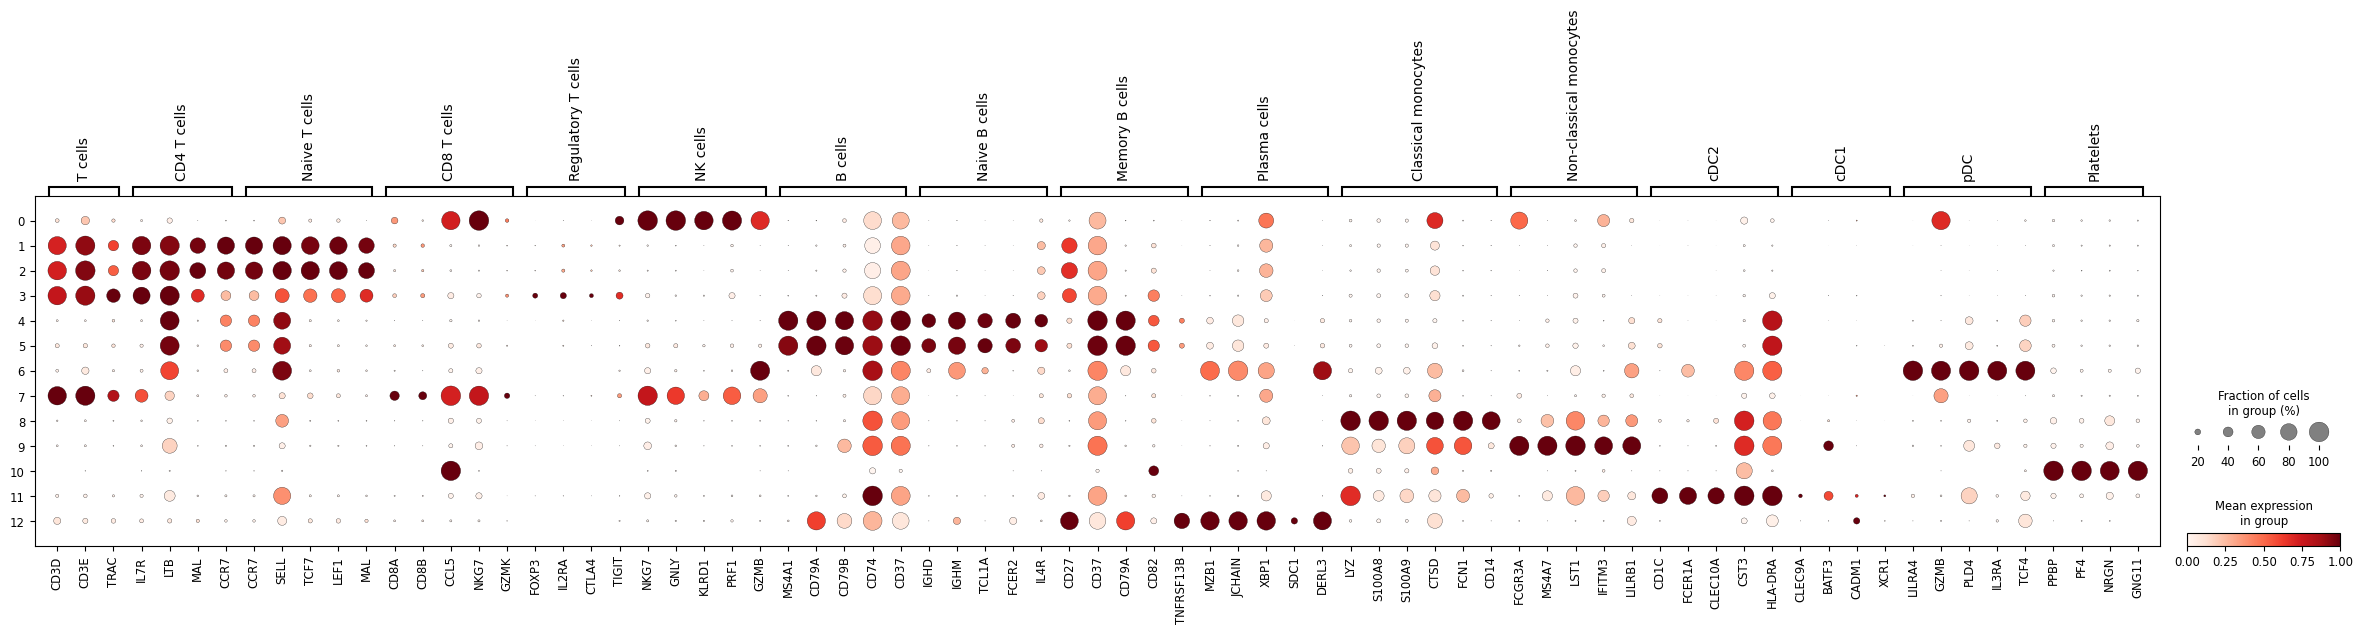

In [38]:
sc.pl.dotplot(
    adata_marker,
    marker_genes,
    groupby="leiden",
    standard_scale="var",
)

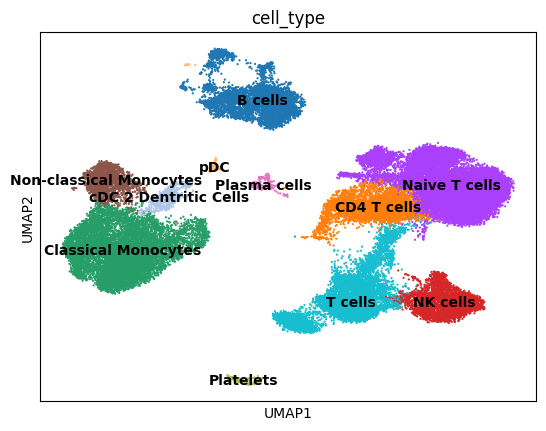

In [39]:
cluster_cell_types = {
    "0": "NK cells",
    "1": "Naive T cells",
    "2": "Naive T cells",
    "3": "CD4 T cells",
    "4": "B cells",
    "5": "B cells",
    "6": "pDC",
    "7": "T cells",
    "8": "Classical Monocytes",
    "9": "Non-classical Monocytes",
    "10": "Platelets",
    "11": "cDC 2 Dentritic Cells",
    "12": "Plasma cells",
}

adata_marker.obs["cell_type"] = (
    adata_marker.obs["leiden"]
    .map(cluster_cell_types)
)

sc.pl.umap(
    adata_marker,
    color="cell_type",
    legend_loc="on data",
    size=10
)

In [51]:
treatment_cell_counts = pd.crosstab(
    adata_marker.obs["treatment"],
    adata_marker.obs["cell_type"]
)

treatment_cell_proportions = treatment_cell_counts.div(
    treatment_cell_counts.sum(axis=1),
    axis=0
)

treatment_cell_proportions.style.format("{:.2%}")

cell_type,B cells,CD4 T cells,Classical Monocytes,NK cells,Naive T cells,Non-classical Monocytes,Plasma cells,Platelets,T cells,cDC 2 Dentritic Cells,pDC
treatment,,,,,,,,,,,
post,11.19%,10.74%,23.39%,9.58%,22.20%,3.90%,0.20%,0.45%,16.78%,1.20%,0.37%
pre,11.73%,6.51%,16.76%,5.61%,39.19%,4.28%,0.69%,0.41%,12.83%,1.64%,0.35%


In [50]:
patient_cell_counts = pd.crosstab(
    [adata_marker.obs["patient"],
    adata_marker.obs["treatment"]
    ],
    adata_marker.obs["cell_type"]
)

patient_cell_proportions = patient_cell_counts.div(
    patient_cell_counts.sum(axis=1),
    axis=0
)

patient_cell_proportions.style.format("{:.2%}")


In [52]:
proportion_table = patient_cell_proportions.reset_index() #moves patient and treatment back into the normal dataframe collumns

pre_treament_props = (
    proportion_table[proportion_table["treatment"] == "pre"]
    .set_index("patient")
    .drop(columns="treatment")
)

post_treatment_props = (
    proportion_table[proportion_table["treatment"] == "post"]
    .set_index("patient")
    .drop(columns="treatment")
)

proportion_change = post_treatment_props - pre_treament_props

proportion_change.style.format("{:.2%}")

cell_type,B cells,CD4 T cells,Classical Monocytes,NK cells,Naive T cells,Non-classical Monocytes,Plasma cells,Platelets,T cells,cDC 2 Dentritic Cells,pDC
patient,,,,,,,,,,,
AD024,5.60%,4.66%,4.19%,-0.03%,-8.94%,-2.83%,0.07%,-0.11%,-1.76%,-0.57%,-0.28%
AD035,-0.40%,2.80%,4.32%,5.09%,-24.69%,2.04%,-1.21%,-0.07%,11.90%,-0.09%,0.30%
AD051,-6.70%,4.73%,-3.02%,5.74%,-0.15%,-3.17%,0.22%,0.02%,3.78%,-1.42%,-0.03%


In [43]:
naive_t = adata_marker[
    adata_marker.obs["cell_type"] == "Naive T cells"
].copy()

pd.crosstab(
    naive_t.obs["patient"],
    naive_t.obs["treatment"]
)



treatment,post,pre
patient,,
AD024,1383,1888
AD035,2547,5775
AD051,1108,642


In [ ]:
genes = [
    "IL4R",
    "IL13RA1",
    "JAK1",
    "JAK2",
    "JAK3",
    "TYK2",
    "STAT6",
    "STAT3",
    "IRS2",
    "GATA3",
]

print([x for x in genes if x in naive_t.var_names]) #confirms all these genes are present in the data

['IL4R', 'IL13RA1', 'JAK1', 'JAK2', 'JAK3', 'TYK2', 'STAT6', 'STAT3', 'IRS2', 'GATA3']


In [ ]:
IL4_expr_df = sc.get.obs_df(
    naive_t,
    keys=["patient", "treatment", *genes]
)

IL4_mean_expr = (
    IL4_expr_df
    .groupby(
        ["patient", "treatment"],
        observed=True
    )[genes]
    .mean()
)

IL4_mean_expr

IL4R   IL13RA1      JAK1      JAK2      JAK3      TYK2  \
patient treatment                                                               
AD024   post       0.053923  0.000115  0.219258  0.008654  0.113095  0.019914   
        pre        0.059168  0.000000  0.200583  0.013554  0.090339  0.020469   
AD035   post       0.062753  0.000049  0.197196  0.009749  0.116000  0.018088   
        pre        0.065892  0.000065  0.197374  0.009295  0.101962  0.015294   
AD051   post       0.084982  0.000000  0.174669  0.009804  0.089987  0.017413   
        pre        0.080795  0.000000  0.173453  0.009096  0.090709  0.019717   

                      STAT6     STAT3      IRS2     GATA3  
patient treatment                                          
AD024   post       0.066522  0.097770  0.004942  0.082518  
        pre        0.062424  0.086800  0.005402  0.080059  
AD035   post       0.054944  0.090809  0.004668  0.073618  
        pre        0.047604  0.139466  0.005561  0.059903  
AD051   post       0.064715  0.102615  0.004399  0.079684  
        pre        0.058722  0.090779  0.004771  0.079606

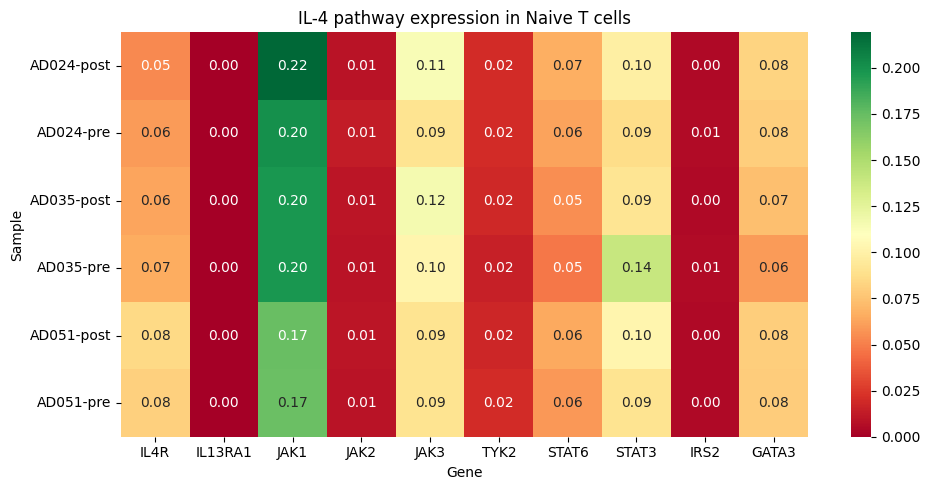

In [ ]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    IL4_mean_expr,
    cmap="RdYlGn",
    annot=True,
    fmt=".3f"
)

plt.title("IL4 pathway gene expression in Naive T cells")
plt.xlabel("Gene")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

In [ ]:

expr = sc.get.obs_df(
    naive_t,
    keys=["patient", "treatment", *naive_t.var_names]
)

mean_expr = (
    expr
    .groupby(
        ["patient", "treatment"],
        observed=True
    )
    .mean()
)

pre = mean_expr.xs("pre", level="treatment")
post = mean_expr.xs("post", level="treatment")

change = post - pre

mean_change = change.mean().sort_values(ascending=False)

print("Genes that increased the most:")
print(mean_change.head(10))
print("")
print("Genes that decreased the most:")
print(mean_change.tail(10))

Genes that increased the most:
MT-ATP8    0.102272
HLA-B      0.091669
HLA-A      0.087461
HLA-E      0.083683
B2M        0.083269
HLA-C      0.082618
CCR7       0.070447
BTG1       0.068881
IL7R       0.067871
GIMAP5     0.051968
dtype: float32

Genes that decreased the most:
RPL37A   -0.065975
RPS21    -0.068253
TMSB10   -0.072343
TXNIP    -0.074236
RPL34    -0.077503
RPS28    -0.081009
MT-CO1   -0.089818
RPL37    -0.095708
RPL41    -0.099603
RPL39    -0.103196
dtype: float32


In [48]:
results = pd.DataFrame({
    "mean_change": change.mean(),
    "AD024_change": change.loc["AD024"],
    "AD035_change": change.loc["AD035"],
    "AD051_change": change.loc["AD051"],
})

print(results.sort_values(
    "mean_change",
    ascending=False
).head(10)
)

print("")

print(results.sort_values(
    "mean_change",
    ascending=False
).tail(10)
)



         mean_change  AD024_change  AD035_change  AD051_change
MT-ATP8     0.102272      0.089582      0.175955      0.041280
HLA-B       0.091669      0.139299      0.029187      0.106521
HLA-A       0.087461      0.122925      0.031392      0.108067
HLA-E       0.083683      0.077002      0.045464      0.128582
B2M         0.083269      0.197156      0.023149      0.029503
HLA-C       0.082618      0.164814     -0.002545      0.085585
CCR7        0.070447      0.065265      0.129543      0.016534
BTG1        0.068881     -0.005877      0.058018      0.154503
IL7R        0.067871      0.027660      0.080680      0.095275
GIMAP5      0.051968      0.020111      0.146819     -0.011025

        mean_change  AD024_change  AD035_change  AD051_change
RPL37A    -0.065975     -0.195876     -0.019379      0.017330
RPS21     -0.068253     -0.206542      0.020118     -0.018335
TMSB10    -0.072343     -0.108994     -0.095701     -0.012335
TXNIP     -0.074236     -0.196496     -0.223913      0.197